<a href="https://colab.research.google.com/github/AlexMoffatt10/PDA4052-EDA-Sales-analysis/blob/main/PDA4052_EDA_Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install openpyxl --quiet
print('Libraries ready')

Libraries ready


In [4]:
from google.colab import files
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]
print(f'File uploaded: {FILENAME}')

Saving Sales Data_PDA_4052.xlsx to Sales Data_PDA_4052 (1).xlsx
File uploaded: Sales Data_PDA_4052 (1).xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = {'Kelly': '#7B2D8B', 'Peter': '#E8873A', 'Pryia': '#2A9D8F'}

print('All libraries imported successfully')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')

All libraries imported successfully
pandas  2.2.2
numpy   2.0.2


---
## Stage 1 — Data Import & Initial Inspection

In [6]:
df = pd.read_excel(FILENAME, header=1)

print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== COLUMN DATA TYPES ===')
print(df.dtypes)

print('\n=== FIRST 5 ROWS ===')
df.head()

=== DATASET SHAPE ===
Rows: 1001, Columns: 7

=== COLUMN DATA TYPES ===
order_id                 int64
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

=== FIRST 5 ROWS ===


,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
0,8999,C406,Kelly,High,Plane,2020-06-12,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12,315.40
2,29988,C006,Kelly,High,Lorry,2020-06-12,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14,8431.37


---
## Stage 2 — Data Type Correction & Initial Statistics

In [7]:
df['order_id']     = df['order_id'].astype(str)
df['customer_id']  = df['customer_id'].astype(str)
df['sales_person'] = df['sales_person'].astype(str)
df['priority']     = df['priority'].astype(str)
df['ship_mode']    = df['ship_mode'].astype(str)
df['date']         = pd.to_datetime(df['date'])
df['value_£']      = pd.to_numeric(df['value_£'], errors='coerce')

print('=== CORRECTED DATA TYPES ===')
print(df.dtypes)
print('\nAll data types correctly assigned')

=== CORRECTED DATA TYPES ===
order_id                object
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

All data types correctly assigned


In [8]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())

print('\n=== DUPLICATE CHECK ===')
print(f'Fully duplicated rows:             {df.duplicated().sum()}')
print(f'Duplicate order_ids (multi-party): {df.duplicated(subset=["order_id"]).sum()}')

print('\n=== SAMPLE OF DUPLICATE ORDER_IDs ===')
df_dup = df[df.duplicated(subset=['order_id'], keep=False)]
df_dup.sort_values('order_id').head(6)

=== MISSING VALUES ===
order_id        0
customer_id     0
sales_person    0
priority        0
ship_mode       0
date            0
value_£         0
dtype: int64

=== DUPLICATE CHECK ===
Fully duplicated rows:             0
Duplicate order_ids (multi-party): 356

=== SAMPLE OF DUPLICATE ORDER_IDs ===


,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
831,10052,C191,Pryia,Not Specified,Plane,2020-09-07,90.47
161,10052,C191,Kelly,Not Specified,Plane,2020-09-07,151.47
160,10052,C191,Kelly,Not Specified,Plane,2020-09-07,512.62
167,10629,C332,Kelly,Critical,Van,2020-09-11,82.56
516,10629,C332,Peter,Critical,Plane,2020-09-11,306.84
817,10658,C400,Pryia,Low,Plane,2020-08-27,1484.97


In [9]:
print('=== DESCRIPTIVE STATISTICS: value_£ ===')
print(df['value_£'].describe().round(2))

print('\n=== TRANSACTIONS PER SALES PERSON ===')
print(df['sales_person'].value_counts())

print('\n=== PRIORITY LEVEL COUNTS ===')
print(df['priority'].value_counts())

print('\n=== DATE RANGE ===')
print(f'From: {df["date"].min().date()}  to  {df["date"].max().date()}')

=== DESCRIPTIVE STATISTICS: value_£ ===
count     1001.00
mean      1778.40
std       3457.46
min          2.45
25%        134.40
50%        417.58
75%       1816.93
max      27448.24
Name: value_£, dtype: float64

=== TRANSACTIONS PER SALES PERSON ===
sales_person
Peter    344
Pryia    338
Kelly    319
Name: count, dtype: int64

=== PRIORITY LEVEL COUNTS ===
priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64

=== DATE RANGE ===
From: 2020-06-12  to  2020-11-30


In [10]:
stat_sw, p_sw = stats.shapiro(df['value_£'].sample(500, random_state=42))

print('=== SHAPIRO-WILK NORMALITY TEST (n=500 sample) ===')
print(f'W statistic : {stat_sw:.4f}')
print(f'p-value     : {p_sw:.6f}')
print()
if p_sw < 0.05:
    print('Result: NON-NORMAL distribution (p < 0.05)')
    print('All inferential tests will use non-parametric methods')
    print('(Kruskal-Wallis, Mann-Whitney U, Spearman correlation)')
else:
    print('Result: Normal distribution (p >= 0.05)')

=== SHAPIRO-WILK NORMALITY TEST (n=500 sample) ===
W statistic : 0.4971
p-value     : 0.000000

Result: NON-NORMAL distribution (p < 0.05)
All inferential tests will use non-parametric methods
(Kruskal-Wallis, Mann-Whitney U, Spearman correlation)


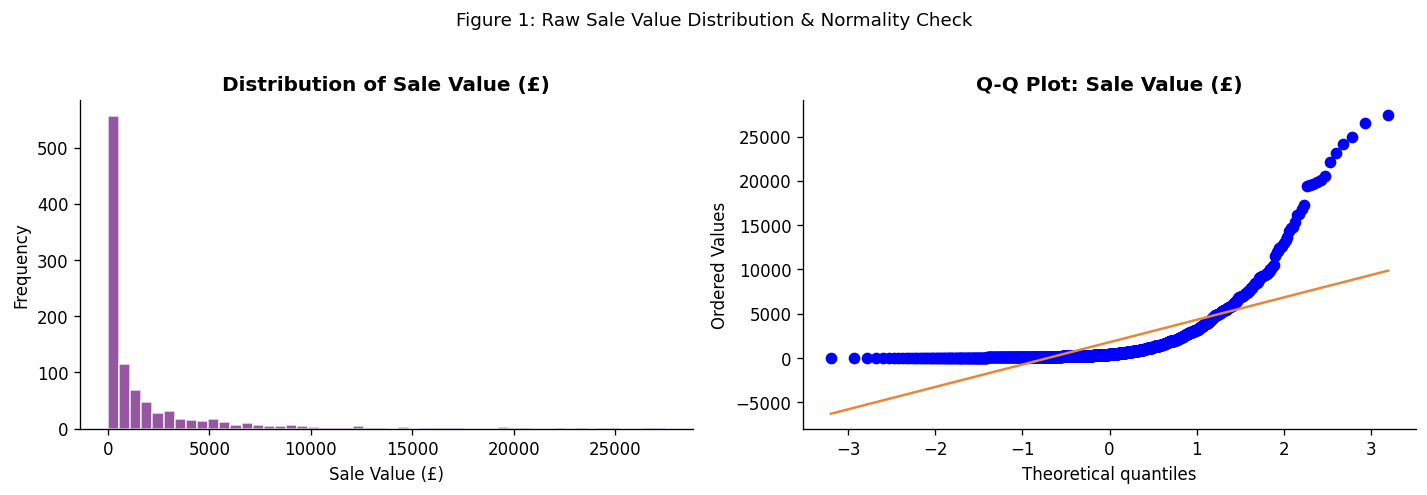

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['value_£'], bins=50, color='#7B2D8B', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Sale Value (£)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Value (£)')
axes[0].set_ylabel('Frequency')

stats.probplot(df['value_£'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Sale Value (£)', fontsize=12, fontweight='bold')
axes[1].get_lines()[1].set_color('#E8873A')

plt.suptitle('Figure 1: Raw Sale Value Distribution & Normality Check', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution_raw.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Stage 3 — Pre-Processing

In [12]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.dropna(subset=['value_£'])
print(f'3a. dropna: {before} -> {len(df_clean)} rows (removed: {before - len(df_clean)})')

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'3b. drop_duplicates: {before} -> {len(df_clean)} rows (removed: {before - len(df_clean)})')

priority_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_clean['priority_num'] = df_clean['priority'].map(priority_map)
print(f'3c. priority_num encoded (Not Specified -> NaN): {df_clean["priority_num"].isna().sum()} NaNs')

df_clean['month']       = df_clean['date'].dt.to_period('M')
df_clean['month_label'] = df_clean['date'].dt.strftime('%b %Y')
df_clean['day_of_week'] = df_clean['date'].dt.day_name()
print('3d. Temporal features added: month, month_label, day_of_week')

Q1 = df_clean['value_£'].quantile(0.25)
Q3 = df_clean['value_£'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
df_clean['outlier_flag'] = df_clean['value_£'] > upper_fence
n_out = df_clean['outlier_flag'].sum()
print(f'3e. IQR fences: £{lower_fence:.2f} – £{upper_fence:.2f}')
print(f'    Outliers flagged (NOT removed): {n_out} ({100*n_out/len(df_clean):.1f}%)')

df_clean['log_value'] = np.log1p(df_clean['value_£'])
print('3f. log_value column added (log1p transform)')

print(f'\nPre-processing complete. Final shape: {df_clean.shape}')

3a. dropna: 1001 -> 1001 rows (removed: 0)
3b. drop_duplicates: 1001 -> 1001 rows (removed: 0)
3c. priority_num encoded (Not Specified -> NaN): 213 NaNs
3d. Temporal features added: month, month_label, day_of_week
3e. IQR fences: £-2389.39 – £4340.73
    Outliers flagged (NOT removed): 122 (12.2%)
3f. log_value column added (log1p transform)

Pre-processing complete. Final shape: (1001, 13)


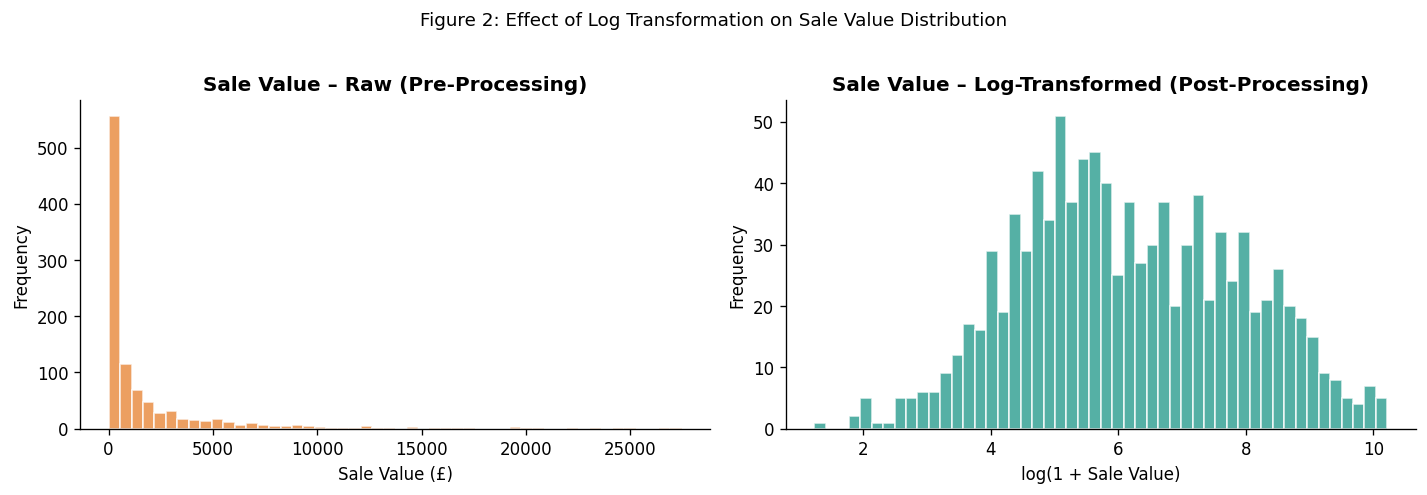

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['value_£'], bins=50, color='#E8873A', edgecolor='white', alpha=0.8)
axes[0].set_title('Sale Value – Raw (Pre-Processing)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Value (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['log_value'], bins=50, color='#2A9D8F', edgecolor='white', alpha=0.8)
axes[1].set_title('Sale Value – Log-Transformed (Post-Processing)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Sale Value)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Figure 2: Effect of Log Transformation on Sale Value Distribution', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig2_pre_post_transform.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Stage 4 — Sales Person Analysis

In [14]:
print('=== SALES PERSON PERFORMANCE SUMMARY ===')
sp_stats = df_clean.groupby('sales_person')['value_£'].agg(
    Transactions='count',
    Total_Revenue='sum',
    Mean_Value='mean',
    Median_Value='median',
    Std_Dev='std'
).round(2)
print(sp_stats)

print('\n=== MONTHLY REVENUE BREAKDOWN ===')
monthly = df_clean.groupby(['month','sales_person'])['value_£'].sum().unstack()
print(monthly.round(2))

=== SALES PERSON PERFORMANCE SUMMARY ===
              Transactions  Total_Revenue  Mean_Value  Median_Value  Std_Dev
sales_person                                                                
Kelly                  319      558659.62     1751.28        366.84  3231.78
Peter                  344      549292.06     1596.78        338.20  3391.70
Pryia                  338      672228.97     1988.84        520.02  3718.74

=== MONTHLY REVENUE BREAKDOWN ===
sales_person      Kelly      Peter      Pryia
month                                        
2020-06        55052.67   26779.29   62447.76
2020-07       104374.60  140824.43  132944.58
2020-08       109806.12  106488.33  116351.04
2020-09       112121.18   88444.06  124025.75
2020-10       108327.39  109380.93  137470.14
2020-11        68977.66   77375.02   98989.70


In [15]:
kelly = df_clean[df_clean['sales_person']=='Kelly']['value_£']
peter = df_clean[df_clean['sales_person']=='Peter']['value_£']
pryia = df_clean[df_clean['sales_person']=='Pryia']['value_£']

H, p_kw = stats.kruskal(kelly, peter, pryia)
print('=== KRUSKAL-WALLIS TEST (overall) ===')
print(f'H statistic : {H:.4f}')
print(f'p-value     : {p_kw:.4f}')
print(f'Significant : {"YES" if p_kw < 0.05 else "NO"} (alpha = 0.05)')

print('\n=== PAIRWISE MANN-WHITNEY U TESTS ===')
pairs = [(kelly, peter, 'Kelly', 'Peter'),
         (kelly, pryia, 'Kelly', 'Pryia'),
         (peter, pryia, 'Peter', 'Pryia')]
for a, b, na, nb in pairs:
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{na:6s} vs {nb:6s}:  U={u:>8.0f},  p={p:.4f}  ->  {sig}')

=== KRUSKAL-WALLIS TEST (overall) ===
H statistic : 6.0269
p-value     : 0.0491
Significant : YES (alpha = 0.05)

=== PAIRWISE MANN-WHITNEY U TESTS ===
Kelly  vs Peter :  U=   57983,  p=0.2063  ->  not significant
Kelly  vs Pryia :  U=   51198,  p=0.2645  ->  not significant
Peter  vs Pryia :  U=   51788,  p=0.0136  ->  SIGNIFICANT


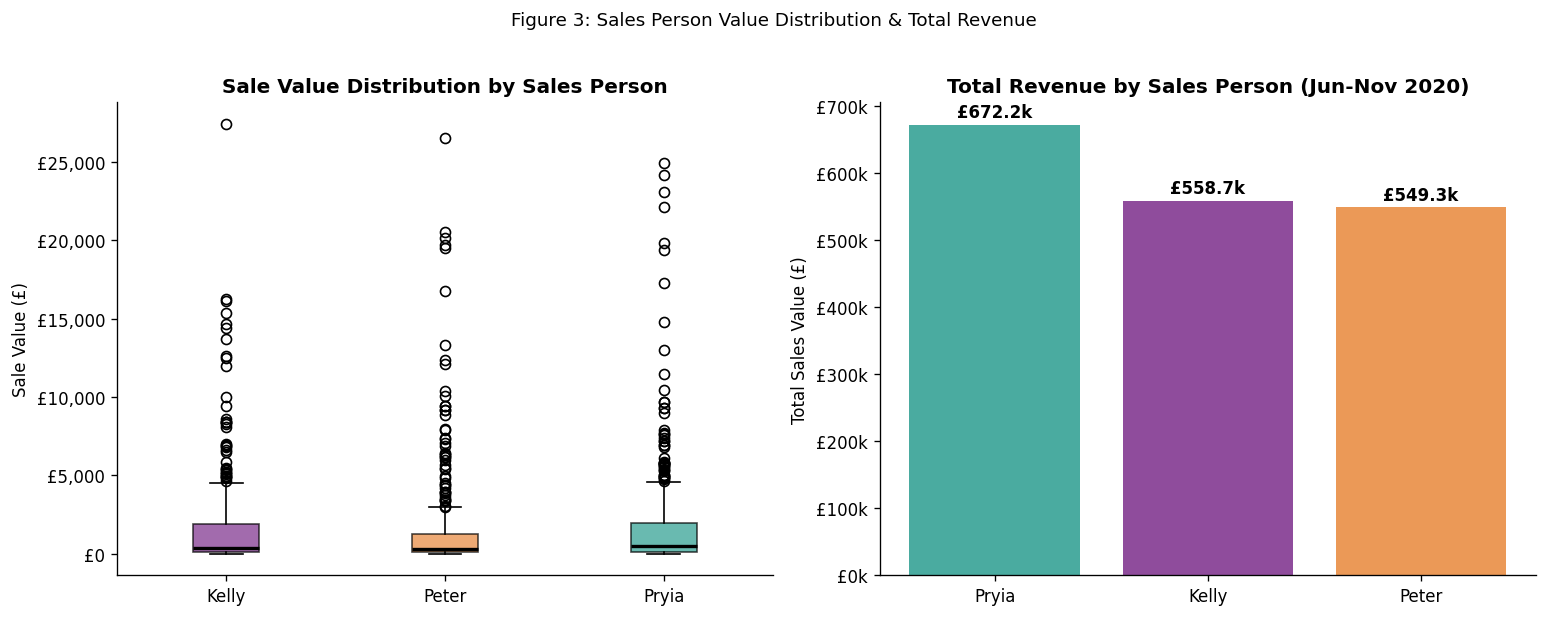

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bp = axes[0].boxplot([kelly.values, peter.values, pryia.values],
                     patch_artist=True, labels=['Kelly','Peter','Pryia'],
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#7B2D8B','#E8873A','#2A9D8F']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Sale Value Distribution by Sales Person', fontweight='bold')
axes[0].set_ylabel('Sale Value (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

totals = df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
bars = axes[1].bar(totals.index, totals.values,
                   color=[PALETTE[k] for k in totals.index], alpha=0.85)
axes[1].set_title('Total Revenue by Sales Person (Jun-Nov 2020)', fontweight='bold')
axes[1].set_ylabel('Total Sales Value (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))
for bar, val in zip(bars, totals.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+5000,
                 f'£{val/1000:.1f}k', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Figure 3: Sales Person Value Distribution & Total Revenue', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig3_salesperson_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


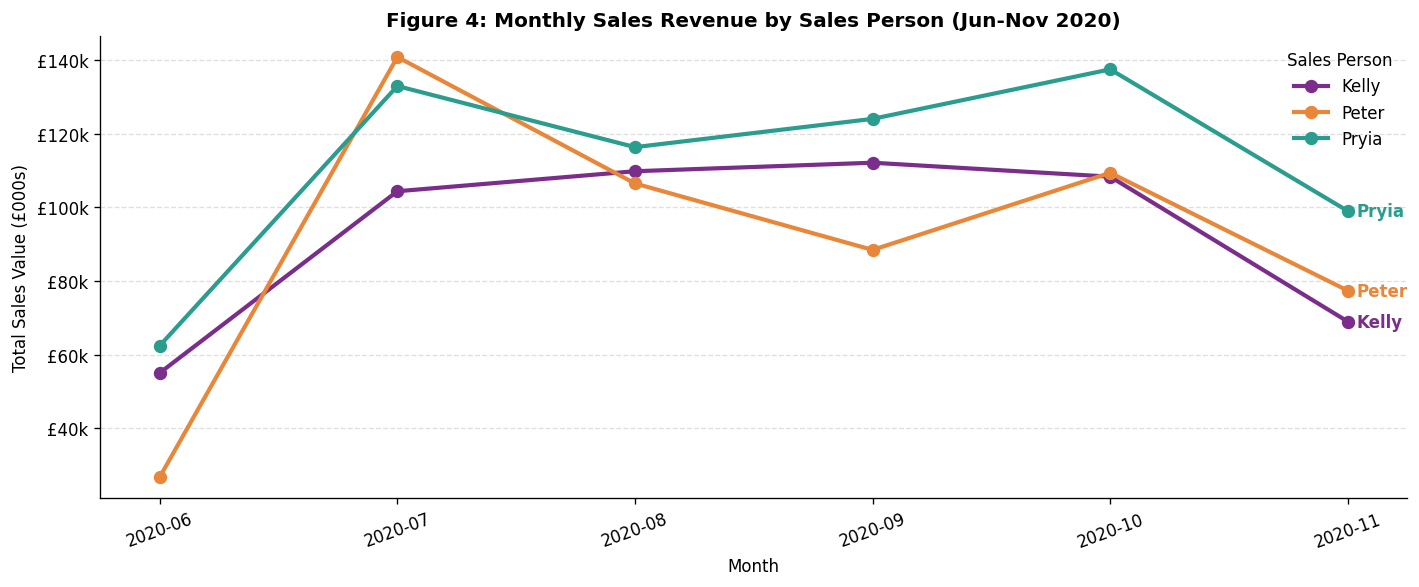

In [17]:
monthly_df = monthly.reset_index()
monthly_df['month_str'] = monthly_df['month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
for person, color in PALETTE.items():
    ax.plot(monthly_df['month_str'], monthly_df[person]/1000,
            marker='o', linewidth=2.5, color=color, label=person, markersize=7)
    ax.annotate(person,
                xy=(monthly_df['month_str'].iloc[-1], monthly_df[person].iloc[-1]/1000),
                xytext=(5,0), textcoords='offset points',
                color=color, fontweight='bold', va='center')

ax.set_title('Figure 4: Monthly Sales Revenue by Sales Person (Jun-Nov 2020)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales Value (£000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}k'))
ax.legend(title='Sales Person', frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig4_monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Stage 5 — Priority vs Value Analysis

In [18]:
print('=== SALE VALUE BY PRIORITY LEVEL ===')
priority_stats = df_clean.groupby('priority')['value_£'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(2)
print(priority_stats)

print('\n=== SPEARMAN RANK CORRELATION (priority vs value_£) ===')
df_pn = df_clean.dropna(subset=['priority_num'])
r_sp, p_sp = stats.spearmanr(df_pn['priority_num'], df_pn['value_£'])
print(f'Spearman r  : {r_sp:.4f}')
print(f'p-value     : {p_sp:.4f}')
print(f'Significant : {"YES" if p_sp < 0.05 else "NO - no meaningful correlation"} (alpha = 0.05)')

print('\n=== KRUSKAL-WALLIS TEST ACROSS PRIORITY GROUPS ===')
groups = [g['value_£'].values for _, g in
          df_clean[df_clean['priority'] != 'Not Specified'].groupby('priority')]
H_p, p_p = stats.kruskal(*groups)
print(f'H statistic : {H_p:.4f}')
print(f'p-value     : {p_p:.4f}')
print(f'Significant : {"YES" if p_p < 0.05 else "NO - no significant difference between groups"} (alpha = 0.05)')

=== SALE VALUE BY PRIORITY LEVEL ===
               Count     Mean  Median      Std
priority                                      
Critical         221  1826.48  435.00  2960.57
High             196  1946.65  496.29  3810.74
Low              200  1462.68  348.37  3124.39
Medium           171  1931.80  566.56  3687.60
Not Specified    213  1747.00  311.04  3704.54

=== SPEARMAN RANK CORRELATION (priority vs value_£) ===
Spearman r  : 0.0634
p-value     : 0.0753
Significant : NO - no meaningful correlation (alpha = 0.05)

=== KRUSKAL-WALLIS TEST ACROSS PRIORITY GROUPS ===
H statistic : 5.9460
p-value     : 0.1143
Significant : NO - no significant difference between groups (alpha = 0.05)


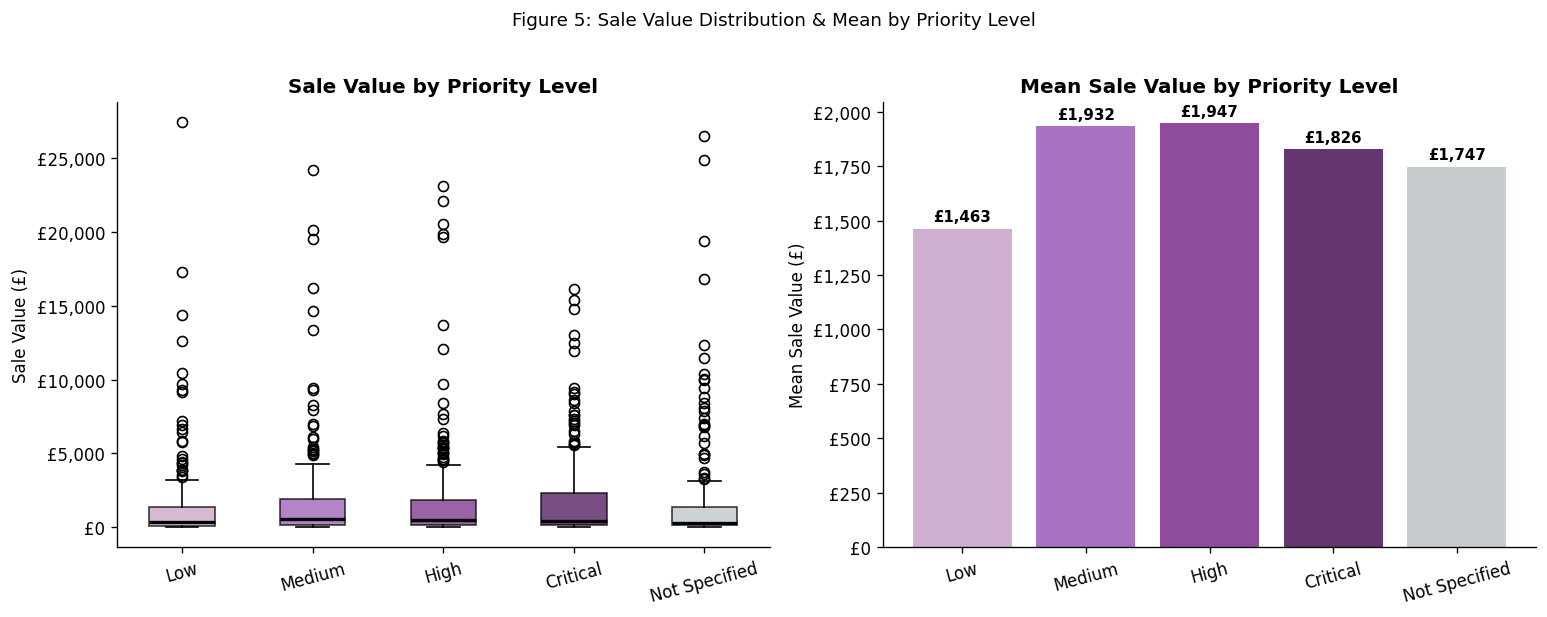

In [19]:
priority_order  = ['Low','Medium','High','Critical','Not Specified']
priority_colors = ['#C8A2C8','#9B59B6','#7B2D8B','#4A1259','#BDC3C7']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bp2 = axes[0].boxplot(
    [df_clean[df_clean['priority']==p]['value_£'].values for p in priority_order],
    patch_artist=True, labels=priority_order,
    medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], priority_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_title('Sale Value by Priority Level', fontweight='bold')
axes[0].set_ylabel('Sale Value (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

means = df_clean.groupby('priority')['value_£'].mean()[priority_order]
bars2 = axes[1].bar(priority_order, means.values, color=priority_colors, alpha=0.85)
axes[1].set_title('Mean Sale Value by Priority Level', fontweight='bold')
axes[1].set_ylabel('Mean Sale Value (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+20,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Figure 5: Sale Value Distribution & Mean by Priority Level', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig5_priority_value.png', bbox_inches='tight', dpi=150)
plt.show()


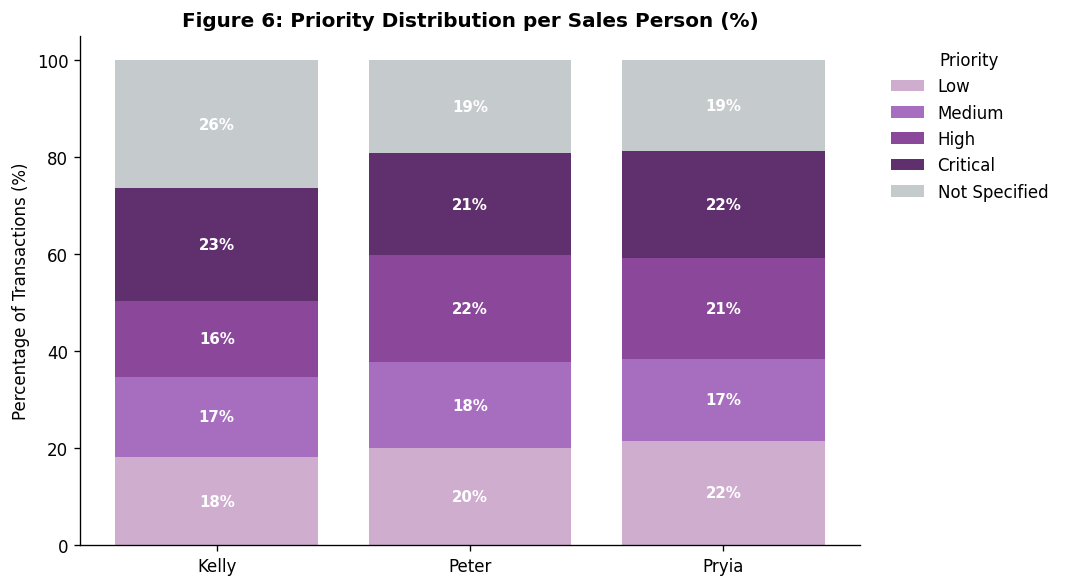

In [20]:
pivot_priority = df_clean.groupby(
    ['sales_person','priority']).size().unstack(fill_value=0)[priority_order]
pct_priority = pivot_priority.div(pivot_priority.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(3)
for col, color in zip(priority_order, priority_colors):
    vals = pct_priority[col].values
    ax.bar(pct_priority.index, vals, bottom=bottom, label=col, color=color, alpha=0.88)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b+v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Figure 6: Priority Distribution per Sales Person (%)', fontweight='bold')
ax.set_ylabel('Percentage of Transactions (%)')
ax.legend(title='Priority', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig('fig6_priority_breakdown.png', bbox_inches='tight', dpi=150)
plt.show()


=== SPEARMAN CORRELATION MATRIX ===
              value_£  log_value  priority_num
value_£        1.0000     1.0000        0.0634
log_value      1.0000     1.0000        0.0634
priority_num   0.0634     0.0634        1.0000


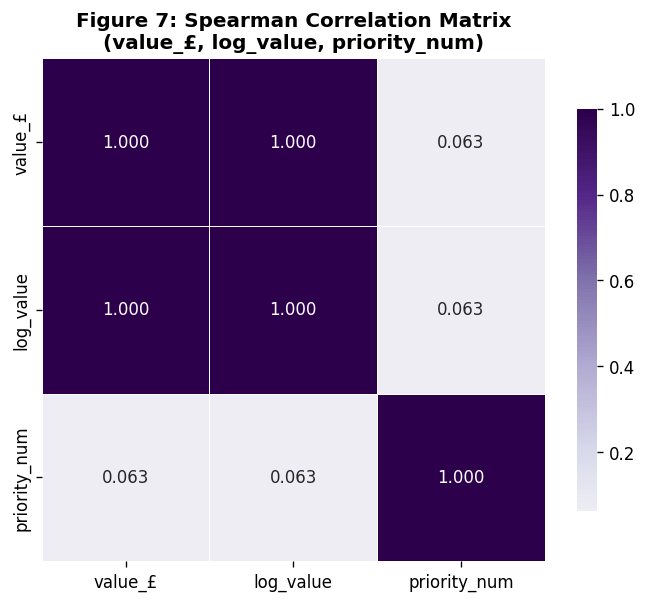

In [21]:
df_corr_all = df_clean[['value_£','log_value','priority_num']].dropna()
corr_matrix = df_corr_all.corr(method='spearman')

print('=== SPEARMAN CORRELATION MATRIX ===')
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='PuOr', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Figure 7: Spearman Correlation Matrix\n(value_£, log_value, priority_num)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Stage 6 — Outlier Analysis

In [22]:
outliers = df_clean[df_clean['outlier_flag']]

print('=== OUTLIER SUMMARY (IQR Method) ===')
print(f'Upper fence            : £{upper_fence:,.2f}')
print(f'Total outliers flagged : {len(outliers)} ({100*len(outliers)/len(df_clean):.1f}%)')
print(f'Outlier value range    : £{outliers["value_£"].min():,.2f} – £{outliers["value_£"].max():,.2f}')
print(f'Outlier mean value     : £{outliers["value_£"].mean():,.2f}')

print('\n=== OUTLIER COUNT PER SALES PERSON ===')
print(outliers['sales_person'].value_counts())

print('\n=== OUTLIER REVENUE CONTRIBUTION ===')
out_rev   = outliers.groupby('sales_person')['value_£'].sum()
total_rev = df_clean.groupby('sales_person')['value_£'].sum()
pct       = (out_rev / total_rev * 100).round(1)
for sp in ['Kelly','Peter','Pryia']:
    print(f'  {sp}: £{out_rev[sp]:>10,.2f} outlier revenue  ({pct[sp]}% of their total)')

=== OUTLIER SUMMARY (IQR Method) ===
Upper fence            : £4,340.73
Total outliers flagged : 122 (12.2%)
Outlier value range    : £4,343.52 – £27,448.24
Outlier mean value     : £9,207.38

=== OUTLIER COUNT PER SALES PERSON ===
sales_person
Pryia    49
Kelly    37
Peter    36
Name: count, dtype: int64

=== OUTLIER REVENUE CONTRIBUTION ===
  Kelly: £331,857.67 outlier revenue  (59.4% of their total)
  Peter: £348,969.07 outlier revenue  (63.5% of their total)
  Pryia: £442,473.05 outlier revenue  (65.8% of their total)


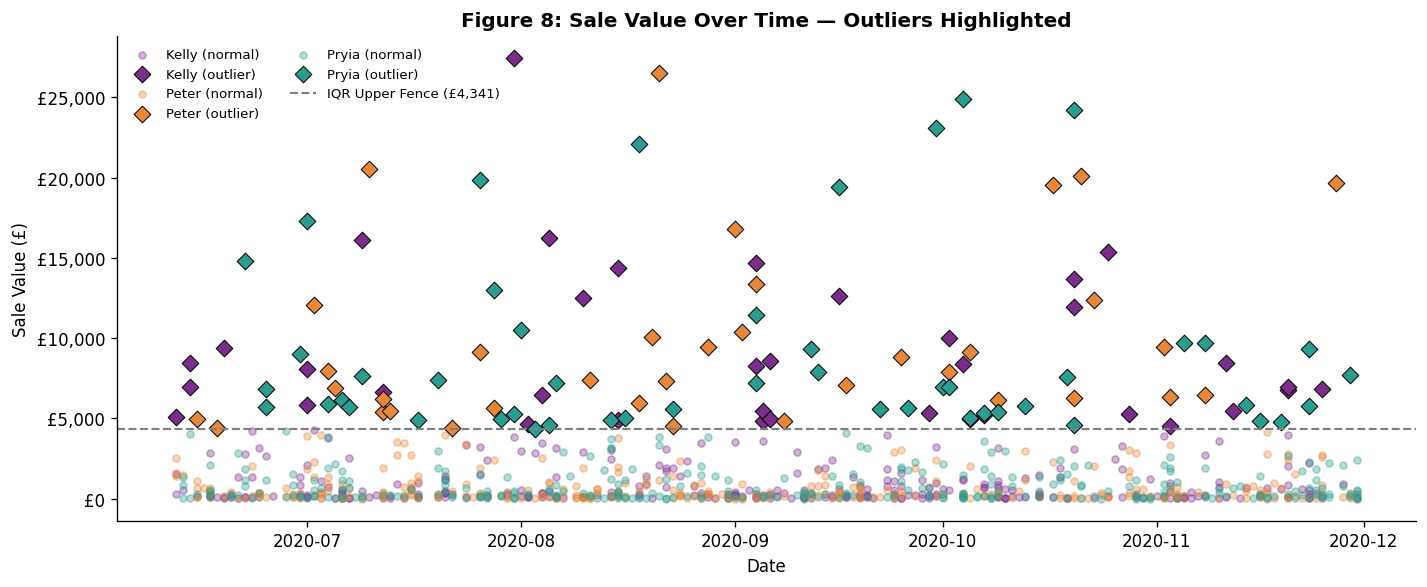

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

for person, color in PALETTE.items():
    sub     = df_clean[df_clean['sales_person'] == person]
    non_out = sub[~sub['outlier_flag']]
    out     = sub[sub['outlier_flag']]
    ax.scatter(non_out['date'], non_out['value_£'],
               color=color, alpha=0.35, s=18, label=f'{person} (normal)')
    ax.scatter(out['date'], out['value_£'],
               color=color, marker='D', s=50, edgecolors='black',
               linewidth=0.6, label=f'{person} (outlier)')

ax.axhline(upper_fence, color='grey', linestyle='--', linewidth=1.3,
           label=f'IQR Upper Fence (£{upper_fence:,.0f})')
ax.set_title('Figure 8: Sale Value Over Time — Outliers Highlighted', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sale Value (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('fig8_outlier_timeline.png', bbox_inches='tight', dpi=150)
plt.show()
